# Notebook 07: Evaluation Benchmark

## Purpose
Run the full ablation grid across all combinations of embedding model, LLM, and RAG condition. Results accumulate in `models/benchmarks.json`, already completed runs are skipped automatically so the notebook is safe to restart.

## Grid
2 embedding models × 2 LLMs × 2 RAG conditions = **8 combinations**

| # | Embedding | LLM | RAG | Run ID |
|---|---|---|---|---|
| 1 | Qwen3-Embedding-0.6B | Qwen3-4B | ✗ | `qwen3-embedding-0.6b__qwen3-4b__no-rag` |
| 2 | Qwen3-Embedding-0.6B | Qwen3-4B | ✓ | `qwen3-embedding-0.6b__qwen3-4b__rag` |
| 3 | Qwen3-Embedding-0.6B | Qwen3-8B | ✗ | `qwen3-embedding-0.6b__qwen3-8b__no-rag` |
| 4 | Qwen3-Embedding-0.6B | Qwen3-8B | ✓ | `qwen3-embedding-0.6b__qwen3-8b__rag` |
| 5 | Octen-Embedding-0.6B | Qwen3-4B | ✗ | `octen-embedding-0.6b__qwen3-4b__no-rag` |
| 6 | Octen-Embedding-0.6B | Qwen3-4B | ✓ | `octen-embedding-0.6b__qwen3-4b__rag` |
| 7 | Octen-Embedding-0.6B | Qwen3-8B | ✗ | `octen-embedding-0.6b__qwen3-8b__no-rag` |
| 8 | Octen-Embedding-0.6B | Qwen3-8B | ✓ | `octen-embedding-0.6b__qwen3-8b__rag` |

Runs 1–2 are already complete (notebook 04). This notebook handles 3–8.

## Benchmark Reference
AMG-RAG: 74.1% F1 on MedQA (GPT-4o-mini + dynamic PubMed KG).

## Outputs
```
models/benchmarks.json          cumulative results — committed to git
models/eval_checkpoints/*.parquet  per-question progress — gitignored
```

## 0. Environment Setup

In [1]:
import gc
import sys
import json
import os
import re
import shutil
import warnings
from datetime import date
from itertools import groupby
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# ── Environment detection ─────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

warnings.filterwarnings('ignore')

# ── Colab: clone repo, install deps ──────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive, userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    if not Path('/content/emma').exists():
        os.system('git clone https://github.com/jaxendutta/emma.git')
    os.chdir('/content/emma')
    os.system('pip install -e . -q')
    os.system('pip install transformers accelerate bitsandbytes faiss-cpu sentence-transformers -q')
    os.system(
        'pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/'
        'releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz -q'
    )
else:
    HF_TOKEN = os.environ.get('HF_TOKEN') or None

# ── Colab: mount Drive and define paths ───────────────────────────────────────
if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_BASE   = Path('/content/drive/MyDrive/emma/models')
    DRIVE_BENCH  = DRIVE_BASE / 'benchmarks.json'
    DRIVE_CKPTS  = DRIVE_BASE / 'eval_checkpoints'
    DRIVE_CKPTS.mkdir(parents=True, exist_ok=True)

# ── Src imports (after chdir so the package resolves correctly) ───────────────
from src.data import REPO_ROOT, load_medqa
from src.retrieval import (
    EMMARetriever,
    _load_models_config,
    get_embedding_config,
    get_model_config,
)

BENCH_PATH  = REPO_ROOT / 'models' / 'benchmarks.json'
CKPT_DIR    = REPO_ROOT / 'models' / 'eval_checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# AMG-RAG reference
AMGRAG_F1  = 74.1
AMGRAG_ACC = 66.34

print(f'Environment     : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root       : {REPO_ROOT}')
print(f'Benchmarks file : {BENCH_PATH}')
print(f'HF token        : {"set" if HF_TOKEN else "not set"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment     : Google Colab
Repo root       : /content/emma
Benchmarks file : /content/emma/models/benchmarks.json
HF token        : set


In [2]:
# ── Colab: restore artifacts from Drive ───────────────────────────────────────
if IN_COLAB:
    # Classifier — needed for specialty routing in every run
    local_clf = REPO_ROOT / 'models' / 'classifier'
    local_clf.mkdir(parents=True, exist_ok=True)
    for f in (DRIVE_BASE / 'classifier').glob('*'):
        if f.is_file():
            shutil.copy(f, local_clf / f.name)
    print(f'> Restored classifier : {[f.name for f in local_clf.glob("*")]}')

    # Vectorstore subfolders — one per embedding model
    for emb_id in _load_models_config()['embeddings_models']:
        drive_vs = DRIVE_BASE / 'vectorstore' / emb_id['id']
        local_vs = REPO_ROOT / 'models' / 'vectorstore' / emb_id['id']
        if drive_vs.exists():
            local_vs.mkdir(parents=True, exist_ok=True)
            for f in drive_vs.glob('*'):
                if f.is_file():
                    shutil.copy(f, local_vs / f.name)
            print(f'> Restored vectorstore/{emb_id["id"]} : {[f.name for f in local_vs.glob("*")]}')
        else:
            print(f'> vectorstore/{emb_id["id"]} not on Drive! Runs using this embedding will be skipped.')

    # benchmarks.json from Drive (authoritative, may have runs from previous sessions)
    if DRIVE_BENCH.exists():
        shutil.copy(DRIVE_BENCH, BENCH_PATH)
        n_done = len([r for r in json.loads(BENCH_PATH.read_text())['runs']
                      if r.get('status') == 'complete'])
        print(f'Restored benchmarks.json : {n_done} complete runs')

    # Per-run checkpoints (resume mid-run after timeout)
    if DRIVE_CKPTS.exists():
        for f in DRIVE_CKPTS.glob('*.parquet'):
            shutil.copy(f, CKPT_DIR / f.name)
        n_ckpts = len(list(CKPT_DIR.glob('*.parquet')))
        if n_ckpts:
            print(f'Restored {n_ckpts} checkpoint(s) — runs will resume mid-question.')

> Restored classifier : ['label_encoder.pkl', 'config.json', 'tfidf_svm.pkl', 'medqa_with_specialty.parquet']
> Restored vectorstore/qwen3-embedding-0.6b : ['texts.pkl', 'index.faiss', 'config.json', 'metadata.pkl']
> Restored vectorstore/octen-embedding-0.6b : ['texts.pkl', 'index.faiss', 'config.json', 'metadata.pkl']


## 1. Grid Definition

All combinations are derived from `config/models.json` and `models/benchmarks.json`.

In [3]:
cfg = _load_models_config()

EMBEDDING_MODELS = cfg['embeddings_models']
LLM_MODELS       = cfg['models']
RAG_CONDITIONS   = [True, False]

def run_id(emb_id: str, llm_id: str, rag: bool) -> str:
    return f"{emb_id}__{llm_id}__{'rag' if rag else 'no-rag'}"

bench         = json.loads(BENCH_PATH.read_text())
completed_ids = {r['id'] for r in bench['runs'] if r.get('status') == 'complete'}

all_runs = [
    {'emb': e, 'llm': l, 'rag': r,
     'id':  run_id(e['id'], l['id'], r)}
    for e in EMBEDDING_MODELS
    for l in LLM_MODELS
    for r in RAG_CONDITIONS
]

pending = [r for r in all_runs if r['id'] not in completed_ids]

grid_df = pd.DataFrame([
    {
        'Run ID':    r['id'],
        'Embedding': r['emb']['name'],
        'LLM':       r['llm']['name'],
        'RAG':       '✓' if r['rag'] else '✗',
        'Status':    '✓ Done' if r['id'] in completed_ids else '⚠ Pending',
    }
    for r in all_runs
])

print(f'Total : {len(all_runs)}  |  Done : {len(completed_ids)}  |  Pending : {len(pending)}')
display(grid_df)

Total : 4  |  Done : 2  |  Pending : 2


,Run ID,Embedding,LLM,RAG,Status
0,qwen3-embedding-0.6b__qwen3-4b__rag,Qwen 3 Embedding 0.6B,Qwen3 4B (Thinking),✓,✓ Done
1,qwen3-embedding-0.6b__qwen3-4b__no-rag,Qwen 3 Embedding 0.6B,Qwen3 4B (Thinking),✗,✓ Done
2,octen-embedding-0.6b__qwen3-4b__rag,Octen Embedding 0.6B,Qwen3 4B (Thinking),✓,⚠ Pending
3,octen-embedding-0.6b__qwen3-4b__no-rag,Octen Embedding 0.6B,Qwen3 4B (Thinking),✗,⚠ Pending


## 2. Evaluation Setup

In [4]:
def extract_answer_letter(response: str, options: dict) -> str | None:
    """
    Extract predicted answer letter (A/B/C/D) from LLM response.
    Strips thinking tokens, tries patterns in priority order,
    falls back to option text matching.
    """
    response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    patterns = [
        r'(?:answer is|answer:|correct answer is|correct option is)\s*:?\s*([A-D])',
        r'^\s*([A-D])[.):\s]',
        r'(?:therefore|thus|so|hence)[^A-D]{0,20}([A-D])\s+(?:is|would be|appears)',
        r'(?:option|choice)\s+([A-D])\b',
        r'\b([A-D])\s+is\s+(?:correct|the answer|most likely)',
        r'\b([A-D])\b',
    ]
    for pattern in patterns:
        m = re.search(pattern, response, re.IGNORECASE | re.MULTILINE)
        if m:
            return m.group(1).upper()
    for letter, text in options.items():
        if str(text).lower()[:40] in response.lower():
            return letter.upper()
    return None

In [5]:
N_EVAL      = 100
RANDOM_SEED = 42

medqa_test = load_medqa(split='test')
eval_df    = medqa_test.sample(
    n=min(N_EVAL, len(medqa_test)), random_state=RANDOM_SEED
).reset_index(drop=True)

print(f'> Questions per run : {len(eval_df)}')
print(f'> Pending runs      : {len(pending)}')
print(f'> Est. total calls  : ~{len(eval_df) * len(pending)}')
display(eval_df[['question', 'answer']].head(3))

[MedQA] Loaded 1,273 rows  (split=test)
> Questions per run : 100
> Pending runs      : 2
> Est. total calls  : ~200


,question,answer
0,A healthy 23-year-old male is undergoing an ex...,Coronary sinus
1,A 31-year-old female patient presents with sig...,Psoriatic arthritis
2,A 47-year-old woman comes to the physician bec...,Intrafascicular infiltration on muscle biopsy


## 3. Ablation Grid

- Outer loop: embedding model; reloads vectorstore only when the embedding changes.
- Inner loop: LLM × RAG; hot-swaps the LLM via `retriever.switch_model()`.
- Checkpoint written after every question; copied to Drive after every completed run.
- Re-run this cell at any time to resume; already-done runs are always skipped.

In [6]:
def _save_bench(bench: dict) -> None:
    """Write benchmarks.json locally and mirror to Drive if in Colab."""
    BENCH_PATH.write_text(json.dumps(bench, indent=2))
    if IN_COLAB:
        shutil.copy(BENCH_PATH, DRIVE_BENCH)


def _sync_checkpoint(checkpoint: Path) -> None:
    """Copy an in-progress checkpoint parquet to Drive if in Colab."""
    if IN_COLAB and checkpoint.exists():
        shutil.copy(checkpoint, DRIVE_CKPTS / checkpoint.name)


def _run_eval(
    retriever,
    eval_df: pd.DataFrame,
    use_rag: bool,
    checkpoint: Path,
) -> dict:
    """
    Evaluate one (LLM, RAG-condition) pair with per-question checkpointing.
    Automatically resumes from checkpoint if it already exists.
    Returns a result dict for benchmarks.json.
    """
    # Resume from checkpoint if present
    rows = []
    if checkpoint.exists():
        rows = pd.read_parquet(checkpoint).to_dict('records')
        print(f'  Resuming: {len(rows)} / {len(eval_df)} questions already done')

    done_qs   = {r['question'] for r in rows}
    remaining = eval_df[~eval_df['question'].str[:100].isin(done_qs)].copy()

    bar_fmt = '    {l_bar}{bar}| {n:,}/{total:,} [{elapsed}<{remaining}]  {postfix}'
    pbar    = tqdm(remaining.iterrows(), total=len(remaining),
                   unit=' q', bar_format=bar_fmt)

    for _, row in pbar:
        q        = row['question']
        options  = row['options']
        correct  = str(row['answer_idx']).upper()
        opts_str = '\n'.join(f"{k}. {v}" for k, v in options.items())
        full_q   = f"{q}\n\nOptions:\n{opts_str}"

        try:
            res        = retriever.answer(full_q, use_rag=use_rag)
            pred       = extract_answer_letter(res.answer, options)
            is_correct = pred == correct if pred else False
        except Exception:
            res, pred, is_correct = None, None, False

        rows.append({
            'question':   q[:100],
            'correct':    correct,
            'pred':       pred,
            'is_correct': is_correct,
            'top_score':  res.metadata.get('top_score') if res else None,
            'latency_s':  res.latency_s if res else None,
        })

        n   = len(rows)
        acc = sum(r['is_correct'] for r in rows) / n * 100
        pbar.set_postfix_str(f'acc={acc:.1f}%')

        # Save checkpoint locally + Drive after every question
        pd.DataFrame(rows).to_parquet(checkpoint, index=False)
        _sync_checkpoint(checkpoint)

    df  = pd.DataFrame(rows)
    acc = df['is_correct'].mean() * 100
    return {
        'accuracy':       round(acc, 2),
        'mean_top_score': round(float(df['top_score'].dropna().mean()), 4)
                          if use_rag and df['top_score'].notna().any() else None,
        'n_eval':         len(df),
    }


# ── Main ablation loop ────────────────────────────────────────────────────────
bench         = json.loads(BENCH_PATH.read_text())
completed_ids = {r['id'] for r in bench['runs'] if r.get('status') == 'complete'}

# Group pending runs by embedding to minimise vectorstore reloads
pending_sorted = sorted(
    [r for r in all_runs if r['id'] not in completed_ids],
    key=lambda x: x['emb']['id'],
)

retriever      = None
current_emb_id = None

for emb_id, emb_group in groupby(pending_sorted, key=lambda x: x['emb']['id']):
    emb_runs = list(emb_group)
    emb_cfg  = emb_runs[0]['emb']

    print(f'\n{"="*65}')
    print(f'  Embedding model : {emb_cfg["name"]}')
    print(f'  Runs in group   : {len(emb_runs)}')
    print(f'{"="*65}')

    # Skip if vectorstore not built for this embedding
    vs_path = REPO_ROOT / 'models' / 'vectorstore' / emb_cfg['id']
    if not (vs_path / 'index.faiss').exists():
        print(f'  ⚠ Vectorstore not found at {vs_path}')
        print(f'  Run notebook 01 with embedding_id="{emb_cfg["id"]}" then re-run this cell.')
        continue

    # Load pipeline (only when embedding model changes)
    if current_emb_id != emb_cfg['id']:
        print(f'  > Loading pipeline for {emb_cfg["name"]}...')
        first_llm = emb_runs[0]['llm']['id']
        retriever = EMMARetriever.load(
            model_id=first_llm,
            emb_model_name=emb_cfg['id'],
            hf_token=HF_TOKEN,
        )
        current_emb_id = emb_cfg['id']

    # Inner loop: LLM × RAG
    for run in emb_runs:
        rid   = run['id']
        llm   = run['llm']
        rag   = run['rag']
        label = f"{llm['name']}  |  RAG={'ON' if rag else 'OFF'}"

        print(f'\n  >> {label}')
        print(f'     {rid}')

        # Hot-swap LLM if needed (vectorstore stays loaded)
        if retriever.model_id != llm['id']:
            retriever.switch_model(llm['id'])

        checkpoint = CKPT_DIR / f'{rid}.parquet'
        result     = _run_eval(retriever, eval_df, rag, checkpoint)

        # Append to benchmarks.json and save immediately
        bench['runs'].append({
            'id':             rid,
            'embedding':      emb_cfg['id'],
            'llm':            llm['id'],
            'rag':            rag,
            'n_eval':         result['n_eval'],
            'accuracy':       result['accuracy'],
            'mean_top_score': result['mean_top_score'],
            'status':         'complete',
            'timestamp':      str(date.today()),
            'notes':          'Notebook 06 ablation grid',
        })
        _save_bench(bench)
        completed_ids.add(rid)

        acc_str = f"{result['accuracy']:.1f}%"
        score_str = f"  mean score={result['mean_top_score']:.4f}" if result['mean_top_score'] else ''
        print(f'     ✓ Accuracy: {acc_str}{score_str}')

        # Remove checkpoint now that the run is saved to benchmarks.json
        # checkpoint.unlink(missing_ok=True)
        # if IN_COLAB:
        #     (DRIVE_CKPTS / checkpoint.name).unlink(missing_ok=True)

pending_remaining = [r for r in all_runs if r['id'] not in completed_ids]
if pending_remaining:
    print(f'\n{len(pending_remaining)} run(s) still pending (missing vectorstore):')
    for r in pending_remaining:
        print(f'  {r["id"]}')
else:
    print('\n✓ All runs complete.')


  Embedding model : Octen Embedding 0.6B
  Runs in group   : 2
  > Loading pipeline for Octen Embedding 0.6B...
Loading vectorstore...
[Vectorstore] Loaded index: 36,723 vectors from /content/emma/models/vectorstore/octen-embedding-0.6b
[Vectorstore] Loaded 36,723 chunk texts from /content/emma/models/vectorstore/octen-embedding-0.6b
Loading embedding model...
[Vectorstore] GPU memory: 14.5 GB free / 14.6 GB total


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[Vectorstore] Embedding model: Octen/Octen-Embedding-0.6B  (dtype=torch.float16, device=cuda)
Loading specialty classifier...
Loading SpaCy NER model...
EMMA retriever ready. Ollama not running — primary: HuggingFace (Qwen/Qwen3-4B)
  To use Ollama: ollama pull qwen3:4b
Pre-loading HuggingFace model as fallback...
Loading Qwen3 4B (Thinking) (Qwen/Qwen3-4B) in 4-bit nf4...
  GPU: Tesla T4  (14.6 GB VRAM)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

  [inference] Ollama not reachable at http://localhost:11434 -> falling back to HF
  [inference] Using HuggingFace (Qwen/Qwen3-4B)


     99%|█████████▉| 99/100 [1:38:30<01:00]  , acc=32.3%

  [inference] Ollama not reachable at http://localhost:11434 -> falling back to HF
  [inference] Using HuggingFace (Qwen/Qwen3-4B)


    100%|██████████| 100/100 [1:39:31<00:00]  , acc=33.0%

     ✓ Accuracy: 33.0%

✓ All runs complete.


## 4. Results

### 4.1. Overall Performance

In [18]:
bench      = json.loads(BENCH_PATH.read_text())
cfg        = _load_models_config()
emb_names  = {m['id']: m['name'] for m in cfg['embeddings_models']}
llm_names  = {m['id']: m['name'] for m in cfg['models']}

runs       = [r for r in bench['runs'] if r.get('status') == 'complete']
results_df = pd.DataFrame(runs)
results_df['Embedding'] = results_df['embedding'].map(emb_names)
results_df['LLM']       = results_df['llm'].map(llm_names)
results_df['RAG']       = results_df['rag'].map({True: '✓', False: '✗'})

display_df = (
    results_df[['Embedding', 'LLM', 'RAG', 'accuracy', 'mean_top_score', 'n_eval']]
    .assign(accuracy=lambda d: (d['accuracy']))
    .rename(columns={
        'accuracy':       'Accuracy %',
        'mean_top_score': 'Mean retrieval score',
        'n_eval':         'N',
    })
    .sort_values(['Embedding', 'LLM', 'RAG'])
    .reset_index(drop=True)
)

print(f'AMG-RAG reference : {AMGRAG_F1}% F1 on MedQA  |  {AMGRAG_ACC}% acc on MedMCQA')
print(f'Note: AMG-RAG uses GPT-4o-mini (~8B). Gap reflects both model size and retrieval strategy.')
display(display_df)

AMG-RAG reference : 74.1% F1 on MedQA  |  66.34% acc on MedMCQA
Note: AMG-RAG uses GPT-4o-mini (~8B). Gap reflects both model size and retrieval strategy.


,Embedding,LLM,RAG,Accuracy %,Mean retrieval score,N
0,Octen Embedding 0.6B,Qwen3 4B (Thinking),✓,44.00,0.6577,100
1,Octen Embedding 0.6B,Qwen3 4B (Thinking),✗,33.00,NaN,100
2,Qwen 3 Embedding 0.6B,Qwen3 4B (Thinking),✓,0.38,0.6480,50
3,Qwen 3 Embedding 0.6B,Qwen3 4B (Thinking),✗,0.42,NaN,50


### 4.2. RAG Delta Table

In [15]:
# RAG delta table: for each (embedding, LLM) pair, RAG accuracy - baseline accuracy
if {'✓', '✗'}.issubset(set(results_df['RAG'])):
    _pct = results_df.copy()
    _pct['accuracy'] = (_pct['accuracy'])
    pivot = _pct.pivot_table(
        index=['Embedding', 'LLM'], columns='RAG', values='accuracy'
    ).rename(columns={'✗': 'Baseline', '✓': 'RAG'})
    pivot['Delta (pp)'] = (pivot['RAG'] - pivot['Baseline']).round(1)
    pivot = pivot.round(1).reset_index()
    print('RAG vs baseline:')
    display(pivot)
else:
    print('Not enough runs yet to compute RAG delta! Need both RAG=ON and RAG=OFF for each pair.')

RAG vs baseline:


RAG,Embedding,LLM,RAG,Baseline,Delta (pp)
0,Octen Embedding 0.6B,Qwen3 4B (Thinking),44.0,33.0,11.0
1,Qwen 3 Embedding 0.6B,Qwen3 4B (Thinking),0.4,0.4,-0.0


### 4.3. Visualizations

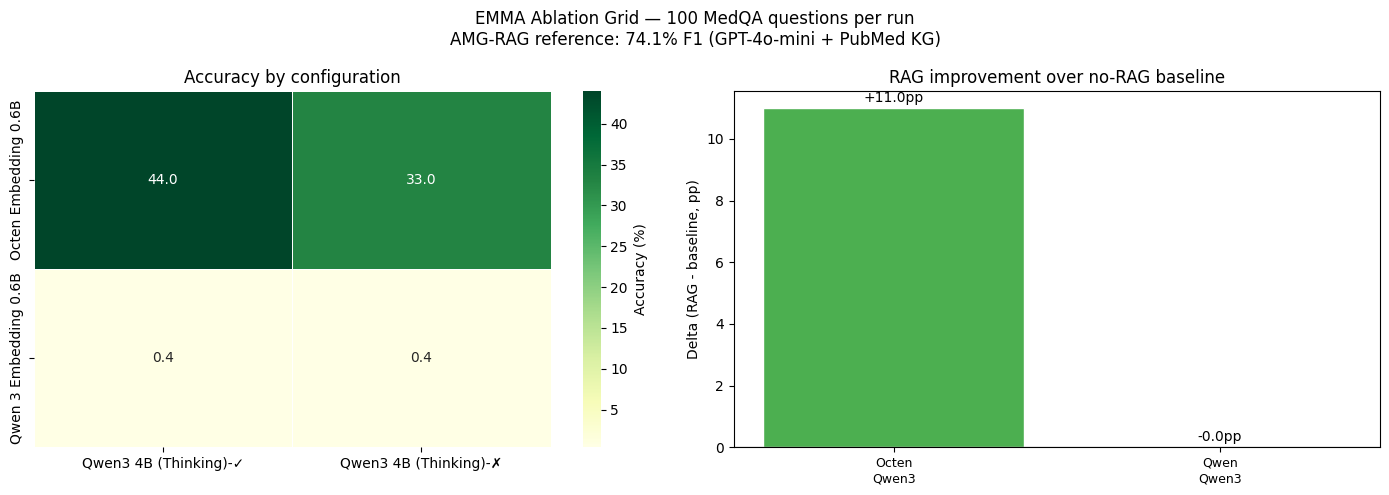

In [16]:
# Visualisation — only rendered when there are at least 2 complete runs
if len(results_df) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: accuracy heatmap
    try:
        hmap = results_df.pivot_table(
            index='Embedding', columns=['LLM', 'RAG'], values='accuracy'
        )
        sns.heatmap(hmap, ax=axes[0], annot=True, fmt='.1f', cmap='YlGn',
                    cbar_kws={'label': 'Accuracy (%)'}, linewidths=0.5)
        axes[0].set_title('Accuracy by configuration')
        axes[0].set_xlabel('')
        axes[0].set_ylabel('')
    except Exception:
        axes[0].text(0.5, 0.5, 'Need more runs for heatmap',
                     ha='center', va='center', transform=axes[0].transAxes)

    # Right: RAG delta bar chart
    if {'✓', '✗'}.issubset(set(results_df['RAG'])):
        colors = ['#4CAF50' if d >= 0 else '#F44336' for d in pivot['Delta (pp)']]
        bars   = axes[1].bar(range(len(pivot)), pivot['Delta (pp)'],
                             color=colors, edgecolor='white')
        labels = pivot.apply(
            lambda r: f"{r['Embedding'].split()[0]}\n{r['LLM'].split()[0]}", axis=1
        )
        axes[1].set_xticks(range(len(pivot)))
        axes[1].set_xticklabels(labels, fontsize=9)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_ylabel('Delta (RAG - baseline, pp)')
        axes[1].set_title('RAG improvement over no-RAG baseline')
        for bar, val in zip(bars, pivot['Delta (pp)']):
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.2 if val >= 0 else -0.8),
                f'{val:+.1f}pp', ha='center', fontsize=10,
            )
    else:
        axes[1].text(0.5, 0.5, 'Need RAG=ON and RAG=OFF runs\nfor delta chart',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.suptitle(
        f'EMMA Ablation Grid — {N_EVAL} MedQA questions per run\n'
        f'AMG-RAG reference: {AMGRAG_F1}% F1 (GPT-4o-mini + PubMed KG)',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()
else:
    print('Not enough runs to visualise yet.')

## 5. Summary

In [17]:
bench = json.loads(BENCH_PATH.read_text())
runs  = [r for r in bench['runs'] if r.get('status') == 'complete']

if runs:
    best_rag  = max((r for r in runs if r['rag']),
                    key=lambda r: r['accuracy'], default=None)
    best_base = max((r for r in runs if not r['rag']),
                    key=lambda r: r['accuracy'], default=None)

    # Best RAG delta across all paired combinations
    rag_deltas = []
    for r in runs:
        if r['rag']:
            baseline = next(
                (b for b in runs
                 if not b['rag']
                 and b['embedding'] == r['embedding']
                 and b['llm'] == r['llm']),
                None,
            )
            if baseline:
                rag_deltas.append({
                    'config': f"{r['embedding']} + {r['llm']}",
                    'delta':  round(r['accuracy'] - baseline['accuracy'], 1),
                })
    best_delta = max(rag_deltas, key=lambda x: x['delta'], default=None)

    summary_df = pd.DataFrame([
        {'Item': 'Runs complete',             'Value': str(len(runs))},
        {'Item': 'Questions per run',         'Value': str(runs[0]['n_eval'])},
        {'Item': 'Best RAG accuracy',
         'Value': f"{best_rag['accuracy']*100:.1f}%  ({best_rag['embedding']} + {best_rag['llm']})"
                  if best_rag else 'N/A'},
        {'Item': 'Best baseline accuracy',
         'Value': f"{best_base['accuracy']*100:.1f}%  ({best_base['embedding']} + {best_base['llm']})"
                  if best_base else 'N/A'},
        {'Item': 'Best RAG delta',
         'Value': f"{best_delta['delta']:+.1f}pp  ({best_delta['config']})"
                  if best_delta else 'N/A (need paired runs)'},
        {'Item': 'AMG-RAG F1 (MedQA)',        'Value': f'{AMGRAG_F1:.1f}%'},
        {'Item': 'AMG-RAG acc (MedMCQA)',     'Value': f'{AMGRAG_ACC:.2f}%'},
        {'Item': 'AMG-RAG note',              'Value': 'GPT-4o-mini + dynamic PubMed KG'},
    ])
    display(summary_df)
else:
    print('> No complete runs yet.')

,Item,Value
0,Runs complete,4
1,Questions per run,50
2,Best RAG accuracy,4400.0% (octen-embedding-0.6b + qwen3-4b)
3,Best baseline accuracy,3300.0% (octen-embedding-0.6b + qwen3-4b)
4,Best RAG delta,+11.0pp (octen-embedding-0.6b + qwen3-4b)
5,AMG-RAG F1 (MedQA),74.1%
6,AMG-RAG acc (MedMCQA),66.34%
7,AMG-RAG note,GPT-4o-mini + dynamic PubMed KG
